<a href="https://colab.research.google.com/github/smagadi/AIML/blob/master/Trading/Trading1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import yfinance as yf
# Download Apple Ticker Data
data = yf.download('AAPL', start='2020-04-01', end='2024-01-01', interval='1d')
print(len(data.index))
for i in range(4, len(data.index), int(len(data.index)/10)):
    data.iloc[i] = np.nan
data.to_csv('AAPL_2009-2010_6m_RAW_1d.csv')

[*********************100%***********************]  1 of 1 completed

944


# 1. Libraries & Sample Data
The first step is to load our Python Libraries and download the sample data. The dataset represents Apple stock price (1d bars) for the year 2010

In [ ]:
# Load Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from IPython.display import display, HTML
# for dataframe display
pd.set_option("display.max_rows", None)
def display_df(df):
    # Puts the scrollbar next to the DataFrame
    display(HTML("<div style='height: 200px; overflow: auto; width: fit-content'>" + df.to_html() + "</div>"))

In [ ]:
# Download Sample Data
data = pd.read_csv('AAPL_2009-2010_6m_RAW_1d.csv')

# 2. Exploratory Data Analysis
Next, we want to analyze our data. Display the data as a dataframe, and plot some relevant data so you can get an idea of what our dataset looks like.

In [ ]:
# Display as Dataframe
display_df(data)

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-04-01,58.5280876159668,60.425494176264635,58.09564428473378,59.886154074244196,176218400.0
3,2020-04-02,59.50472640991211,59.558174794508744,57.55387149331358,58.38960582657782,165934000.0
4,2020-04-03,58.64956283569336,59.691798977456195,58.05677432512775,58.98725744365528,129880000.0
5,2020-04-06,63.7659912109375,63.92147268414862,60.58583124007948,60.95510622630932,201820400.0
6,2020-04-07,NaN,NaN,NaN,NaN,NaN
7,2020-04-08,64.64061737060547,64.95644407485085,63.46476010469618,63.83160337197063,168895200.0
8,2020-04-09,65.10704803466797,65.61237949299203,64.3077616237392,65.27954490531218,161834800.0
9,2020-04-13,66.38494873046875,66.49427732074086,64.58228739111088,65.1847957247921,131022800.0


In [ ]:
# Index data by Date

data.set_index(data.index)
display_df(data)

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-04-01,58.5280876159668,60.425494176264635,58.09564428473378,59.886154074244196,176218400.0
3,2020-04-02,59.50472640991211,59.558174794508744,57.55387149331358,58.38960582657782,165934000.0
4,2020-04-03,58.64956283569336,59.691798977456195,58.05677432512775,58.98725744365528,129880000.0
5,2020-04-06,63.7659912109375,63.92147268414862,60.58583124007948,60.95510622630932,201820400.0
6,2020-04-07,NaN,NaN,NaN,NaN,NaN
7,2020-04-08,64.64061737060547,64.95644407485085,63.46476010469618,63.83160337197063,168895200.0
8,2020-04-09,65.10704803466797,65.61237949299203,64.3077616237392,65.27954490531218,161834800.0
9,2020-04-13,66.38494873046875,66.49427732074086,64.58228739111088,65.1847957247921,131022800.0


# 3. Data Cleaning
Next, we need to clean our data for training our model. This requires removal of NaN values.

In [ ]:
# Check for null values
print('Number of Null Values =', data.isnull().sum())

Number of Null Values = index      0
Price      0
Close     11
High      11
Low       11
Open      11
Volume    11
dtype: int64


In [ ]:
# forward fill missing values
data=data.ffill()
display_df(data)

,index,Price,Close,High,Low,Open,Volume
0,0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,1,Date,AAPL,AAPL,AAPL,AAPL,AAPL
2,2,2009-04-01,3.274470806121826,3.283809691962862,3.1298621761931824,3.135887653092018,589372000.0
3,3,2009-04-02,3.395578622817993,3.457037265097586,3.3073074195197982,3.3181530741054517,812366800.0
4,4,2009-04-03,3.4943952560424805,3.498613089839417,3.419982628084669,3.4401671710718955,636241200.0
5,5,2009-04-06,3.5685064792633057,3.5775442909574506,3.412751143767058,3.4627617897039666,658064400.0
6,6,2009-04-07,3.5685064792633057,3.5775442909574506,3.412751143767058,3.4627617897039666,658064400.0
7,7,2009-04-08,3.504335403442383,3.5184944619428062,3.4519149897907626,3.477522448138891,455630000.0
8,8,2009-04-09,3.6022486686706543,3.6152030409154703,3.5537443872980643,3.5676033854876916,530756800.0
9,9,2009-04-13,3.6218295097351074,3.644725910918796,3.5850753214779965,3.6155027614221544,389236400.0


In [ ]:
# Check for null values
print('Number of Null Values =', data.isnull().sum())

Number of Null Values = Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


# 4. Feature Definition
Now that we have cleaned our stock data, we can define some financial indicaors, or "features" to train our model on. We will be calculating some popular indicators: 20-day Close Moving Average, 5-day Close Moving Average, 20-day Close Bollinger Bands, and 20-day Historical Volatility of Close Price.

In [ ]:
data['MA5'] = data['Close'].rolling(window=5).mean()
data['MA20'] = data['Close'].rolling(window=20).mean()
data['STD20'] = data['Close'].rolling(window=20).std()
data['BB_upper'] = data['MA20'] + (data['STD20'] * 2)
data['BB_lower'] = data['MA20'] - (data['STD20'] * 2)
data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))
data['Vol20'] = data['Log_Ret'].rolling(window=20).std() * np.sqrt(252)
display_df(data)

DataError: No numeric types to aggregate

In [ ]:
# Remove rows with MA=NaN
data = data.dropna(axis=0)
display_df(data)

,Open,High,Low,Close,Adj Close,Volume,MA5,MA20,STD20,BB_upper,BB_lower,Log_Ret,Vol20
Date,,,,,,,,,,,,,
2009-04-30,4.507857,4.535714,4.461429,4.493929,3.790841,4.984896e+08,4.453572,4.312857,0.128631,4.570118,4.055596,0.005499,0.287544
2009-05-01,4.492857,4.569643,4.492857,4.544286,3.833319,3.975160e+08,4.477429,4.338804,0.119607,4.578017,4.099590,0.011143,0.267026
2009-05-04,4.580000,4.723214,4.560000,4.716786,3.978833,6.093584e+08,4.529857,4.367518,0.137583,4.642685,4.092351,0.037257,0.278159
2009-05-05,4.580000,4.723214,4.560000,4.716786,3.978833,6.093584e+08,4.588214,4.391839,0.154067,4.699974,4.083704,0.000000,0.273591
2009-05-06,4.761786,4.767857,4.650714,4.732143,3.991786,4.735388e+08,4.640786,4.416929,0.166724,4.750376,4.083481,0.003251,0.272976
2009-05-07,4.726071,4.728214,4.567857,4.609286,3.888150,5.317760e+08,4.663857,4.439679,0.159903,4.759484,4.119873,-0.026305,0.283717
2009-05-08,4.608571,4.686786,4.509286,4.613929,3.892066,4.679640e+08,4.677786,4.456857,0.159209,4.775274,4.138440,0.001007,0.271348
2009-05-11,4.548929,4.677143,4.540000,4.627500,3.903514,4.046588e+08,4.659929,4.473554,0.158692,4.790938,4.156169,0.002937,0.271302
2009-05-12,4.627143,4.632500,4.401786,4.443571,3.748361,6.094816e+08,4.605286,4.484464,0.147862,4.780187,4.188741,-0.040558,0.306691


<Axes: xlabel='Date'>

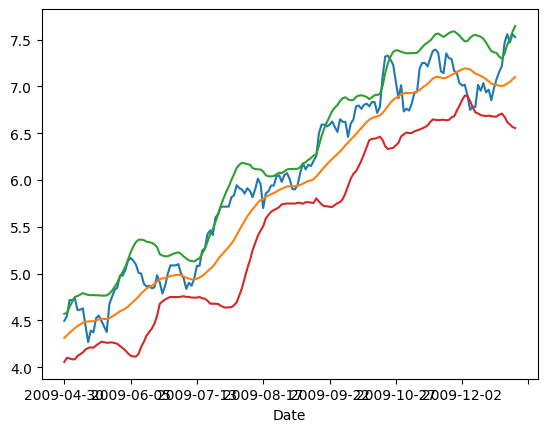

In [ ]:
# Plot Features: Close, MA20, BB Upper, BB Lower
data['Close'].plot()
data['MA20'].plot()
data['BB_upper'].plot()
data['BB_lower'].plot()

<Axes: xlabel='Date'>

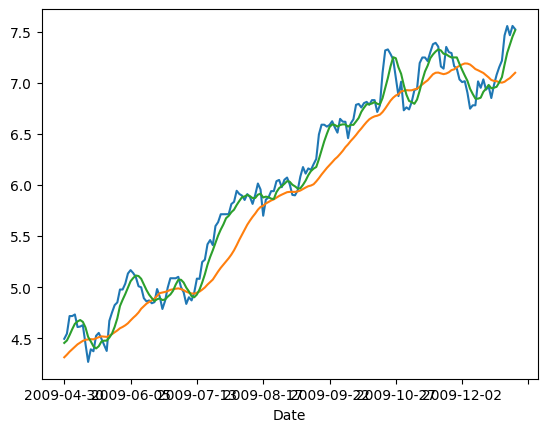

In [ ]:
# Plot Features: Close, MA20, MA5
data['Close'].plot()
data['MA20'].plot()
data['MA5'].plot()

<Axes: xlabel='Date'>

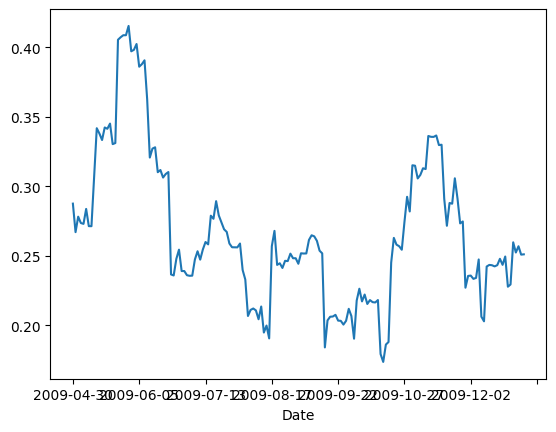

In [ ]:
# Plot Features: Volatility
data['Vol20'].plot()

In [ ]:
data.to_csv('AAPL_2009-2010_6m_all_features_1d.csv')